# SOLUTION RISK DATASET

## Imports and visualization definition

In [11]:
from __future__ import annotations

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

from dataclasses import dataclass
from typing import Any, Optional, TypedDict

In [12]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Optional, TypedDict

import numpy as np
import pandas as pd


class PlotConfig(TypedDict, total=False):
    df: pd.DataFrame
    x1_col: str
    x2_col: Optional[str]
    class_col: str
    n_grid: int
    point_opacity: float


@dataclass(frozen=True)
class _ResolvedPlotConfig:
    df: pd.DataFrame
    x1_col: str
    x2_col: Optional[str]
    class_col: str
    n_grid: int
    point_opacity: float
    idx: int


_CLASS_COLORS = ["red", "blue", "green", "gold"]


def plot_multiple_plots(
    df: pd.DataFrame,
    config: list[PlotConfig],
    backend_plotly: bool = False,
    kde_bool: bool = True,
):
    """
    Plot multiple scatter subplots with automatic axis-sharing layout.

    Layout rules
    ------------
    1. Same x1_col -> same visual column and shared X axis.
    2. Same x2_col, or x2_col=None numeric-class Y -> same visual row and shared Y axis.
    3. Unrelated axis groups are plotted as separated blocks, max 3 block columns.
    4. Mixed cases are handled through connected components of the shared-axis graph.

    Each subplot
    ------------
    - Scatter plot colored by class.
    - X axis: x1_col.
    - Y axis:
        - x2_col if provided.
        - numeric-encoded class_col if x2_col is None.
    - Optional KDE:
        - horizontal KDE below X axis for x1_col.
        - vertical KDE beside Y axis for x2_col when x2_col is not None.

    Notes
    -----
    In notebooks, do not call fig.show() if the returned figure is the last line.
    Let Jupyter display the returned figure once.

    Parameters
    ----------
    df:
        Default DataFrame used when a config does not provide its own df.
    config:
        List of PlotConfig dictionaries.
    backend_plotly:
        If True, returns a Plotly Figure.
        If False, returns a Matplotlib Figure.
    kde_bool:
        Whether to draw class-wise KDE marginal plots.

    Returns
    -------
    matplotlib.figure.Figure or plotly.graph_objects.Figure
    """

    resolved = _resolve_configs(df, config)

    if not resolved:
        raise ValueError("config must contain at least one PlotConfig.")

    components = _build_axis_components(resolved)

    if backend_plotly:
        return _plot_plotly(components, kde_bool=kde_bool)

    return _plot_matplotlib(components, kde_bool=kde_bool)


# ---------------------------------------------------------------------
# Config and layout helpers
# ---------------------------------------------------------------------


def _resolve_configs(
    default_df: pd.DataFrame,
    configs: list[PlotConfig],
) -> list[_ResolvedPlotConfig]:
    resolved: list[_ResolvedPlotConfig] = []

    for i, cfg in enumerate(configs):
        if "x1_col" not in cfg:
            raise ValueError(f"config[{i}] is missing required key `x1_col`.")

        local_df = cfg.get("df", default_df)
        x1_col = cfg["x1_col"]
        x2_col = cfg.get("x2_col", None)
        class_col = cfg.get("class_col", "risk")
        n_grid = int(cfg.get("n_grid", 300))
        point_opacity = float(cfg.get("point_opacity", 0.45))

        required_cols = [x1_col, class_col]
        if x2_col is not None:
            required_cols.append(x2_col)

        missing = [c for c in required_cols if c not in local_df.columns]
        if missing:
            raise ValueError(
                f"config[{i}] references missing columns: {missing}. "
                f"Available columns: {list(local_df.columns)}"
            )

        resolved.append(
            _ResolvedPlotConfig(
                df=local_df,
                x1_col=x1_col,
                x2_col=x2_col,
                class_col=class_col,
                n_grid=n_grid,
                point_opacity=point_opacity,
                idx=i,
            )
        )

    return resolved


def _y_key(cfg: _ResolvedPlotConfig) -> str:
    if cfg.x2_col is None:
        return "__numeric_class_y__"
    return cfg.x2_col


def _y_label(cfg: _ResolvedPlotConfig) -> str:
    if cfg.x2_col is None:
        return f"{cfg.class_col} numeric"
    return cfg.x2_col


def _build_axis_components(configs: list[_ResolvedPlotConfig]) -> list[dict[str, Any]]:
    """
    Build connected components in a bipartite graph.

    x-node = x1_col
    y-node = x2_col, or special numeric-class Y node when x2_col is None

    Each connected component becomes a visual block.
    """

    adjacency: dict[tuple[str, str], set[tuple[str, str]]] = {}
    config_by_edge: dict[tuple[str, str], list[_ResolvedPlotConfig]] = {}

    for cfg in configs:
        x_node = ("x", cfg.x1_col)
        y_node = ("y", _y_key(cfg))

        adjacency.setdefault(x_node, set()).add(y_node)
        adjacency.setdefault(y_node, set()).add(x_node)

        config_by_edge.setdefault((cfg.x1_col, _y_key(cfg)), []).append(cfg)

    seen: set[tuple[str, str]] = set()
    components: list[dict[str, Any]] = []

    for start in adjacency:
        if start in seen:
            continue

        stack = [start]
        nodes: set[tuple[str, str]] = set()

        while stack:
            node = stack.pop()
            if node in seen:
                continue

            seen.add(node)
            nodes.add(node)
            stack.extend(adjacency[node] - seen)

        xs = [n[1] for n in nodes if n[0] == "x"]
        ys = [n[1] for n in nodes if n[0] == "y"]

        xs = _sort_by_first_config_order(xs, configs, attr="x1_col")
        ys = _sort_y_keys_by_first_config_order(ys, configs)

        cells: list[dict[str, Any]] = []

        for x in xs:
            for y in ys:
                cfgs = config_by_edge.get((x, y), [])
                for duplicate_idx, cfg in enumerate(cfgs):
                    cells.append(
                        {
                            "x": x,
                            "y": y,
                            "cfg": cfg,
                            "duplicate_idx": duplicate_idx,
                        }
                    )

        # Duplicate x/y pairs cannot occupy the same subplot cell.
        # They remain in the same x column and get duplicate rows.
        expanded_ys: list[tuple[str, int]] = []
        max_duplicates_by_y: dict[str, int] = {}

        for y in ys:
            max_duplicates_by_y[y] = 1

        for x in xs:
            for y in ys:
                max_duplicates_by_y[y] = max(
                    max_duplicates_by_y[y],
                    len(config_by_edge.get((x, y), [])) or 1,
                )

        for y in ys:
            for duplicate_idx in range(max_duplicates_by_y[y]):
                expanded_ys.append((y, duplicate_idx))

        components.append(
            {
                "xs": xs,
                "ys": expanded_ys,
                "cells": cells,
            }
        )

    # Larger components first usually gives a better visual layout.
    components.sort(key=lambda c: len(c["xs"]) * len(c["ys"]), reverse=True)

    return components


def _sort_by_first_config_order(
    values: list[str],
    configs: list[_ResolvedPlotConfig],
    attr: str,
) -> list[str]:
    order: dict[str, int] = {}

    for cfg in configs:
        value = getattr(cfg, attr)
        if value not in order:
            order[value] = cfg.idx

    return sorted(values, key=lambda v: order.get(v, 10**9))


def _sort_y_keys_by_first_config_order(
    values: list[str],
    configs: list[_ResolvedPlotConfig],
) -> list[str]:
    order: dict[str, int] = {}

    for cfg in configs:
        value = _y_key(cfg)
        if value not in order:
            order[value] = cfg.idx

    return sorted(values, key=lambda v: order.get(v, 10**9))


# ---------------------------------------------------------------------
# Data helpers
# ---------------------------------------------------------------------


def _class_mapping(series: pd.Series) -> dict[Any, int]:
    values = pd.Series(series.dropna().unique())

    try:
        values = values.sort_values()
    except Exception:
        values = values.astype(str).sort_values()

    classes = list(values)

    if len(classes) > 4:
        raise ValueError(
            f"Expected at most 4 classes, got {len(classes)}: {classes}"
        )

    return {cls: i for i, cls in enumerate(classes)}


def _numeric_class_y(series: pd.Series) -> pd.Series:
    mapping = _class_mapping(series)
    return series.map(mapping).astype(float)


def _clean_xy(
    df: pd.DataFrame,
    x_col: str,
    y_col: Optional[str],
    class_col: str,
) -> pd.DataFrame:
    cols = [x_col, class_col]
    if y_col is not None:
        cols.append(y_col)

    out = df[cols].copy()

    out[x_col] = pd.to_numeric(out[x_col], errors="coerce")

    if y_col is not None:
        out[y_col] = pd.to_numeric(out[y_col], errors="coerce")
    else:
        out["__numeric_class_y__"] = _numeric_class_y(out[class_col])

    return out.dropna()


def _kde_1d(values: np.ndarray, n_grid: int = 300) -> tuple[np.ndarray, np.ndarray]:
    """
    Simple Gaussian KDE using Silverman's bandwidth.

    This avoids requiring scipy.
    """

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size < 2:
        return np.array([]), np.array([])

    vmin = values.min()
    vmax = values.max()

    if np.isclose(vmin, vmax):
        pad = 0.5 if np.isclose(vmin, 0) else abs(vmin) * 0.1
        vmin -= pad
        vmax += pad

    std = values.std(ddof=1)

    if not np.isfinite(std) or std == 0:
        std = max(abs(values.mean()) * 0.1, 1.0)

    bandwidth = 1.06 * std * values.size ** (-1 / 5)
    bandwidth = max(bandwidth, np.finfo(float).eps)

    grid = np.linspace(vmin, vmax, n_grid)
    z = (grid[:, None] - values[None, :]) / bandwidth

    density = np.exp(-0.5 * z**2).sum(axis=1)
    density /= values.size * bandwidth * np.sqrt(2 * np.pi)

    return grid, density


# ---------------------------------------------------------------------
# Matplotlib backend
# ---------------------------------------------------------------------


def _plot_matplotlib(
    components: list[dict[str, Any]],
    kde_bool: bool,
):
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.patches import Rectangle

    n_blocks = len(components)
    block_cols = min(3, n_blocks)
    block_rows = int(np.ceil(n_blocks / block_cols))

    # Estimate global logical grid size.
    # This makes the plot larger when there are several shared-axis rows/columns.
    logical_cols_per_block_row: list[int] = []
    logical_rows_per_block_row: list[int] = []

    for br in range(block_rows):
        row_components = components[br * block_cols : (br + 1) * block_cols]

        logical_cols_per_block_row.append(
            sum(len(component["xs"]) for component in row_components)
        )

        logical_rows_per_block_row.append(
            max(len(component["ys"]) for component in row_components)
        )

    logical_cols = max(logical_cols_per_block_row)
    logical_rows = sum(logical_rows_per_block_row)

    fig = plt.figure(
        figsize=(
            max(9.0, 5.0 * logical_cols),
            max(6.0, 4.2 * logical_rows),
        ),
        constrained_layout=True,
    )

    outer = GridSpec(
        block_rows,
        block_cols,
        figure=fig,
        wspace=0.14,
        hspace=0.16,
    )

    for block_idx, component in enumerate(components):
        block_r = block_idx // block_cols
        block_c = block_idx % block_cols

        xs = component["xs"]
        ys = component["ys"]
        cells = component["cells"]

        n_rows = len(ys)
        n_cols = len(xs)

        block_spec = outer[block_r, block_c]

        # Border axis for disconnected component separation.
        border_ax = fig.add_subplot(block_spec)
        border_ax.set_xticks([])
        border_ax.set_yticks([])
        border_ax.patch.set_alpha(0)

        for spine in border_ax.spines.values():
            spine.set_visible(False)

        border_ax.add_patch(
            Rectangle(
                (0, 0),
                1,
                1,
                transform=border_ax.transAxes,
                fill=False,
                linewidth=1.0,
                edgecolor="0.65",
            )
        )

        border_ax.set_title(f"Axis group {block_idx + 1}", fontsize=11)

        inner = GridSpecFromSubplotSpec(
            n_rows,
            n_cols,
            subplot_spec=block_spec,
            wspace=0.08,
            hspace=0.10,
        )

        x_share_axes: dict[str, Any] = {}
        y_share_axes: dict[str, Any] = {}

        cell_lookup = {
            (cell["x"], cell["y"], cell["duplicate_idx"]): cell["cfg"]
            for cell in cells
        }

        for row_idx, (y_key, duplicate_idx) in enumerate(ys):
            for col_idx, x_key in enumerate(xs):
                cfg = cell_lookup.get((x_key, y_key, duplicate_idx))

                if cfg is None:
                    blank = fig.add_subplot(inner[row_idx, col_idx])
                    blank.axis("off")
                    continue

                has_y_kde = cfg.x2_col is not None and kde_bool

                if kde_bool and has_y_kde:
                    # Narrow KDE strips.
                    sub = GridSpecFromSubplotSpec(
                        2,
                        2,
                        subplot_spec=inner[row_idx, col_idx],
                        width_ratios=[8.0, 0.9],
                        height_ratios=[8.0, 0.9],
                        wspace=0.025,
                        hspace=0.025,
                    )

                    main_spec = sub[0, 0]
                    xkde_spec = sub[1, 0]
                    ykde_spec = sub[0, 1]

                elif kde_bool:
                    # Narrow X KDE strip.
                    sub = GridSpecFromSubplotSpec(
                        2,
                        1,
                        subplot_spec=inner[row_idx, col_idx],
                        height_ratios=[8.0, 0.9],
                        hspace=0.025,
                    )

                    main_spec = sub[0, 0]
                    xkde_spec = sub[1, 0]
                    ykde_spec = None

                else:
                    sub = GridSpecFromSubplotSpec(
                        1,
                        1,
                        subplot_spec=inner[row_idx, col_idx],
                    )

                    main_spec = sub[0, 0]
                    xkde_spec = None
                    ykde_spec = None

                sharex = x_share_axes.get(x_key)
                sharey = y_share_axes.get(y_key)

                ax = fig.add_subplot(main_spec, sharex=sharex, sharey=sharey)

                if sharex is None:
                    x_share_axes[x_key] = ax

                if sharey is None:
                    y_share_axes[y_key] = ax

                xkde_ax = (
                    fig.add_subplot(xkde_spec, sharex=x_share_axes[x_key])
                    if xkde_spec is not None
                    else None
                )

                ykde_ax = (
                    fig.add_subplot(ykde_spec, sharey=y_share_axes[y_key])
                    if ykde_spec is not None
                    else None
                )

                _draw_matplotlib_subplot(
                    ax=ax,
                    xkde_ax=xkde_ax,
                    ykde_ax=ykde_ax,
                    cfg=cfg,
                    kde_bool=kde_bool,
                )

                if row_idx < n_rows - 1:
                    plt.setp(ax.get_xticklabels(), visible=False)
                else:
                    ax.set_xlabel(cfg.x1_col)

                if col_idx > 0:
                    plt.setp(ax.get_yticklabels(), visible=False)
                else:
                    ax.set_ylabel(_y_label(cfg))

                if xkde_ax is not None:
                    xkde_ax.set_yticks([])
                    xkde_ax.set_xlabel(cfg.x1_col)

                    for side in ["left", "right", "top"]:
                        xkde_ax.spines[side].set_visible(False)

                if ykde_ax is not None:
                    ykde_ax.set_xticks([])
                    ykde_ax.set_ylabel("")

                    for side in ["bottom", "right", "top"]:
                        ykde_ax.spines[side].set_visible(False)

    return fig


def _draw_matplotlib_subplot(
    ax,
    xkde_ax,
    ykde_ax,
    cfg: _ResolvedPlotConfig,
    kde_bool: bool,
) -> None:
    data = _clean_xy(cfg.df, cfg.x1_col, cfg.x2_col, cfg.class_col)
    class_map = _class_mapping(data[cfg.class_col])

    y_col = cfg.x2_col if cfg.x2_col is not None else "__numeric_class_y__"

    for cls, cls_idx in class_map.items():
        cls_data = data[data[cfg.class_col] == cls]
        color = _CLASS_COLORS[cls_idx]

        ax.scatter(
            cls_data[cfg.x1_col],
            cls_data[y_col],
            s=18,
            alpha=cfg.point_opacity,
            color=color,
            label=str(cls),
            edgecolors="none",
        )

        if kde_bool and xkde_ax is not None:
            grid, density = _kde_1d(
                cls_data[cfg.x1_col].to_numpy(),
                n_grid=cfg.n_grid,
            )

            if grid.size:
                xkde_ax.plot(grid, density, color=color, linewidth=1.2)
                xkde_ax.fill_between(grid, 0, density, color=color, alpha=0.20)

        if kde_bool and ykde_ax is not None and cfg.x2_col is not None:
            grid, density = _kde_1d(
                cls_data[cfg.x2_col].to_numpy(),
                n_grid=cfg.n_grid,
            )

            if grid.size:
                ykde_ax.plot(density, grid, color=color, linewidth=1.2)
                ykde_ax.fill_betweenx(grid, 0, density, color=color, alpha=0.20)

    ax.set_title(f"{cfg.x1_col} vs {_y_label(cfg)}", fontsize=10)
    ax.grid(True, alpha=0.25)

    handles, labels = ax.get_legend_handles_labels()

    if handles:
        ax.legend(
            handles,
            labels,
            title=cfg.class_col,
            fontsize=8,
            title_fontsize=8,
            loc="best",
            frameon=True,
        )


# ---------------------------------------------------------------------
# Plotly backend
# ---------------------------------------------------------------------


def _plot_plotly(
    components: list[dict[str, Any]],
    kde_bool: bool,
):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    n_blocks = len(components)
    block_cols = min(3, n_blocks)
    block_rows = int(np.ceil(n_blocks / block_cols))

    # Compute block placement in a global logical grid.
    row_offsets: list[int] = []
    col_offsets_by_block_row: list[list[int]] = []

    current_row_offset = 0

    for br in range(block_rows):
        row_components = components[br * block_cols : (br + 1) * block_cols]
        max_rows = max(len(c["ys"]) for c in row_components)

        row_offsets.append(current_row_offset)

        current_col_offset = 0
        col_offsets: list[int] = []

        for component in row_components:
            col_offsets.append(current_col_offset)
            current_col_offset += len(component["xs"])

        col_offsets_by_block_row.append(col_offsets)
        current_row_offset += max_rows

    logical_rows = current_row_offset

    logical_cols = max(
        sum(
            len(component["xs"])
            for component in components[br * block_cols : (br + 1) * block_cols]
        )
        for br in range(block_rows)
    )

    # Each logical cell gets:
    # - main row
    # - optional x KDE row
    # - main col
    # - optional y KDE col
    if kde_bool:
        rows = logical_rows * 2
        cols = logical_cols * 2
    else:
        rows = logical_rows
        cols = logical_cols

    specs = [[None for _ in range(cols)] for _ in range(rows)]

    for r in range(logical_rows):
        for c in range(logical_cols):
            if kde_bool:
                specs[2 * r][2 * c] = {}
                specs[2 * r + 1][2 * c] = {}
                specs[2 * r][2 * c + 1] = {}
            else:
                specs[r][c] = {}

    if kde_bool:
        row_heights = [
            0.92 if i % 2 == 0 else 0.08
            for i in range(rows)
        ]

        column_widths = [
            0.92 if i % 2 == 0 else 0.08
            for i in range(cols)
        ]
    else:
        row_heights = None
        column_widths = None

    fig = make_subplots(
        rows=rows,
        cols=cols,
        specs=specs,
        horizontal_spacing=0.018,
        vertical_spacing=0.025,
        row_heights=row_heights,
        column_widths=column_widths,
    )

    shown_legend: set[str] = set()

    for block_idx, component in enumerate(components):
        br = block_idx // block_cols
        bc = block_idx % block_cols

        row_offset = row_offsets[br]
        col_offset = col_offsets_by_block_row[br][bc]

        xs = component["xs"]
        ys = component["ys"]

        cell_lookup = {
            (cell["x"], cell["y"], cell["duplicate_idx"]): cell["cfg"]
            for cell in component["cells"]
        }

        for row_idx, (y_key, duplicate_idx) in enumerate(ys):
            for col_idx, x_key in enumerate(xs):
                cfg = cell_lookup.get((x_key, y_key, duplicate_idx))

                if cfg is None:
                    continue

                logical_r = row_offset + row_idx
                logical_c = col_offset + col_idx

                if kde_bool:
                    main_row = 2 * logical_r + 1
                    main_col = 2 * logical_c + 1
                    xkde_row = main_row + 1
                    ykde_col = main_col + 1 if cfg.x2_col is not None else None
                else:
                    main_row = logical_r + 1
                    main_col = logical_c + 1
                    xkde_row = None
                    ykde_col = None

                _draw_plotly_subplot(
                    fig=fig,
                    cfg=cfg,
                    main_row=main_row,
                    main_col=main_col,
                    xkde_row=xkde_row,
                    ykde_col=ykde_col,
                    shown_legend=shown_legend,
                )

    fig.update_layout(
        height=max(650, 410 * logical_rows),
        width=max(950, 520 * logical_cols),
        template="plotly_white",
        legend_title_text="class",
    )

    return fig


def _draw_plotly_subplot(
    fig,
    cfg: _ResolvedPlotConfig,
    main_row: int,
    main_col: int,
    xkde_row: Optional[int],
    ykde_col: Optional[int],
    shown_legend: set[str],
) -> None:
    import plotly.graph_objects as go

    data = _clean_xy(cfg.df, cfg.x1_col, cfg.x2_col, cfg.class_col)
    class_map = _class_mapping(data[cfg.class_col])

    y_col = cfg.x2_col if cfg.x2_col is not None else "__numeric_class_y__"

    for cls, cls_idx in class_map.items():
        cls_data = data[data[cfg.class_col] == cls]
        color = _CLASS_COLORS[cls_idx]
        legend_name = str(cls)

        fig.add_trace(
            go.Scattergl(
                x=cls_data[cfg.x1_col],
                y=cls_data[y_col],
                mode="markers",
                marker=dict(
                    color=color,
                    opacity=cfg.point_opacity,
                    size=5,
                ),
                name=legend_name,
                showlegend=legend_name not in shown_legend,
            ),
            row=main_row,
            col=main_col,
        )

        shown_legend.add(legend_name)

        if xkde_row is not None:
            grid, density = _kde_1d(
                cls_data[cfg.x1_col].to_numpy(),
                n_grid=cfg.n_grid,
            )

            if grid.size:
                fig.add_trace(
                    go.Scatter(
                        x=grid,
                        y=density,
                        mode="lines",
                        line=dict(color=color),
                        fill="tozeroy",
                        opacity=0.35,
                        showlegend=False,
                    ),
                    row=xkde_row,
                    col=main_col,
                )

        if ykde_col is not None and cfg.x2_col is not None:
            grid, density = _kde_1d(
                cls_data[cfg.x2_col].to_numpy(),
                n_grid=cfg.n_grid,
            )

            if grid.size:
                fig.add_trace(
                    go.Scatter(
                        x=density,
                        y=grid,
                        mode="lines",
                        line=dict(color=color),
                        fill="tozerox",
                        opacity=0.35,
                        showlegend=False,
                    ),
                    row=main_row,
                    col=ykde_col,
                )

    fig.update_xaxes(title_text=cfg.x1_col, row=main_row, col=main_col)
    fig.update_yaxes(title_text=_y_label(cfg), row=main_row, col=main_col)

    if xkde_row is not None:
        fig.update_yaxes(
            showticklabels=False,
            title_text="",
            row=xkde_row,
            col=main_col,
        )

    if ykde_col is not None:
        fig.update_xaxes(
            showticklabels=False,
            title_text="",
            row=main_row,
            col=ykde_col,
        )

## Raw data visualization

/tmp/ipykernel_6871/2058929050.py:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



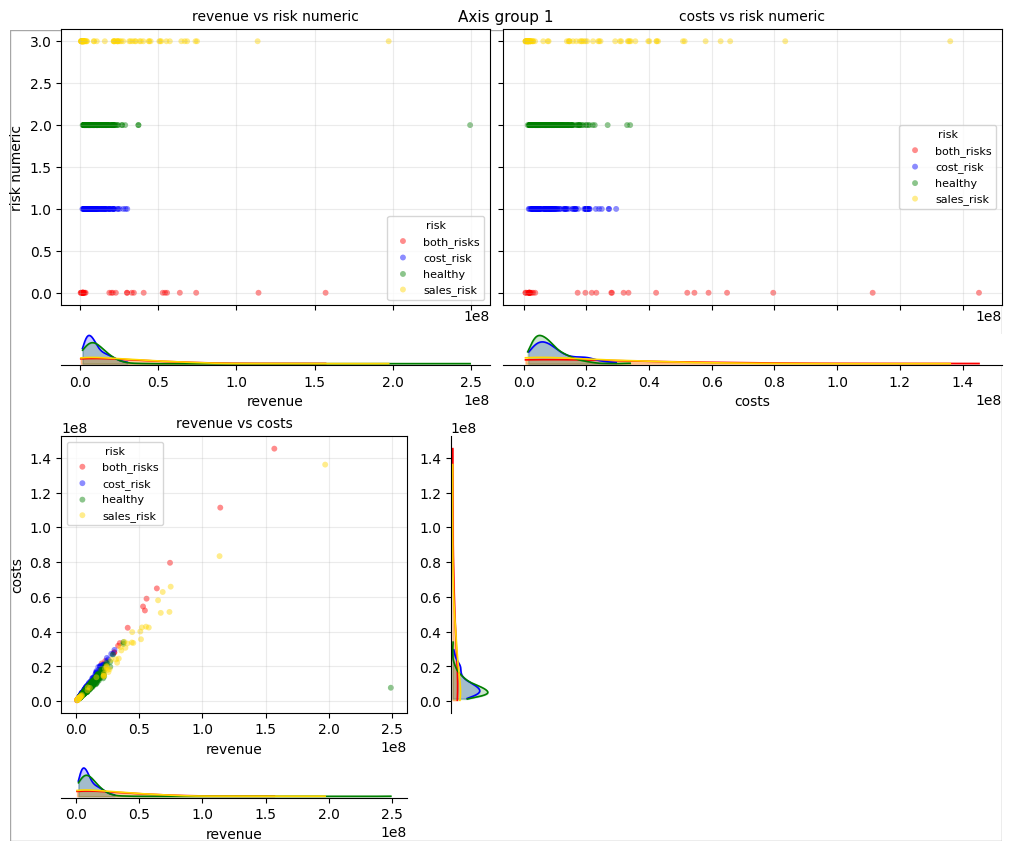

In [13]:
url = "https://raw.githubusercontent.com/jparisu/CUNEF-Resources/refs/heads/main/datasets/risk/risk_test_dataset_1.csv"
df = pd.read_csv(url)
plot_multiple_plots(
    df=df,
    backend_plotly=False,
    kde_bool=True,
    config=[
        {"x1_col": "revenue"},
        {"x1_col": "costs"},
        {"x1_col": "revenue", "x2_col": "costs"},
    ],
).show()

## Log scale visualization  

In [14]:
df["log_revenue"] = np.log(df["revenue"])
df["log_costs"] = np.log(df["costs"])
plot_multiple_plots(
    df=df,
    backend_plotly=True,
    kde_bool=True,
    config=[
        {"x1_col": "log_revenue"},
        {"x1_col": "log_costs"},
        {"x1_col": "log_revenue", "x2_col": "log_costs"},
    ],
).show()

## Margin visualization

In [15]:
# Profit Margin = Revenue - Costs / Revenue
df["profit_margin"] = (df["revenue"] - df["costs"]) / df["revenue"]

# Remove outliers in profit margin with z-score > 3
margin_mean = df["profit_margin"].mean()
margin_std = df["profit_margin"].std()
df = df[
    (df["profit_margin"] >= margin_mean - 3 * margin_std)
    & (df["profit_margin"] <= margin_mean + 3 * margin_std)
]

# revenue square = (revenue - mean revenue)^2
df["revenue_squared"] = (df["log_revenue"] - df["log_revenue"].mean()) ** 2

# Remove outliers in revenue_squared with z-score > 3
revenue_squared_mean = df["revenue_squared"].mean()
revenue_squared_std = df["revenue_squared"].std()
df = df[
    (df["revenue_squared"] >= revenue_squared_mean - 3 * revenue_squared_std)
    & (df["revenue_squared"] <= revenue_squared_mean + 3 * revenue_squared_std)
]

plot_multiple_plots(
    df=df,
    backend_plotly=True,
    kde_bool=True,
    config=[
        {"x1_col": "profit_margin"},
        {"x1_col": "revenue_squared"},
    ],
).show()

In [16]:
"""
p = (0.18 - profit_margin) / 0.08
cost_risk_factor =
    1.1 * p
    + 0.45 · max(0, p) ** 2
    - 0.55 · audited
    + market_shift_cost

r = (log(revenue) - 16) / 1
sales_risk_factor =
    0.90 · r*2
    + 0.30 · r
    - 0.55 · audited
    + market_shift_sales
"""
df["p"] = (0.18 - df["profit_margin"]) / 0.08
df["cost_risk_factor"] = (
    1.1 * df["p"]
    + 0.45 * np.maximum(0, df["p"]) ** 2
)

df["r"] = (df["log_revenue"] - 16) / 1
df["sales_risk_factor"] = (
    0.90 * df["r"] ** 2
    + 0.30 * df["r"]
)

plot_multiple_plots(
    df=df,
    backend_plotly=True,
    kde_bool=True,
    config=[
        # {"x1_col": "cost_risk_factor"},
        # {"x1_col": "sales_risk_factor"},
        {"x1_col": "cost_risk_factor", "x2_col": "sales_risk_factor"},
    ],
).show()

In [17]:
# market_x = MultiLabel OHE in market_focus
df["market_Industrial"] = df["market_focus"].apply(lambda x: 1 if "Industrial" in x else 0)
df["market_Ads"] = df["market_focus"].apply(lambda x: 1 if "Ads" in x else 0)
df["market_Contract"] = df["market_focus"].apply(lambda x: 1 if "Contract" in x else 0)
df["market_Scale"] = df["market_focus"].apply(lambda x: 1 if "Scale" in x else 0)

"""
market_shift_cost =
     0.70 if Industrial
     0.00 if Ads
    -0.50 if Contract
     0.45 if Scale

market_shift_sales =
     0.00 if Industrial
     0.80 if Ads
    -0.50 if Contract
     0.45 if Scale
"""
df["market_shift_cost"] = (
    0.70 * df["market_Industrial"]
    + 0.00 * df["market_Ads"]
    - 0.50 * df["market_Contract"]
    + 0.45 * df["market_Scale"]
)

df["market_shift_sales"] = (
    0.00 * df["market_Industrial"]
    + 0.80 * df["market_Ads"]
    - 0.50 * df["market_Contract"]
    + 0.45 * df["market_Scale"]
)

df["cost_risk_factor"] = df["cost_risk_factor"] + df["market_shift_cost"] - 0.55 * df["audited"]
df["sales_risk_factor"] = df["sales_risk_factor"] + df["market_shift_sales"] - 0.55 * df["audited"]

plot_multiple_plots(
    df=df,
    backend_plotly=True,
    kde_bool=True,
    config=[
        # {"x1_col": "cost_risk_factor"},
        # {"x1_col": "sales_risk_factor"},
        {"x1_col": "cost_risk_factor", "x2_col": "sales_risk_factor"},
    ],
).show()